In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import geopandas as gpd
import pandas as pd
from matplotlib.colors import ListedColormap
from unidecode import unidecode
import matplotlib.patches as mpatches
import country_converter as coco

# Planilha

In [88]:
arquivo1 = "docs/jusbrasil/jusbrasil.xlsx"
arquivo2 = "docs/jusbrasil/respostas_danos_ambientais_df_completo.xlsx"
arquivo3 = "docs/df_jusbrasil_iopc_juscraper.xlsx"
df = pd.read_excel(arquivo1, sheet_name='Anexos')
respostas_danos_ambientais_df_completo = pd.read_excel(arquivo2)
df_jusbrasil_iopc_juscraper = pd.read_excel(arquivo3)

In [6]:
#quantidade e tipos de arquivos
df['Tipo de anexo'].value_counts()

Tipo de anexo
DG_INDEFINIDO    6112
DOCUMENTO        2700
PETICAO          2670
CERTIDAO         1783
DECISAO          1188
DESPACHO          979
SENTENCA          397
INICIAL           247
PROCURACAO        241
OUTRO             233
ACORDAO            56
ATA                54
LAUDO              13
Name: count, dtype: int64

In [5]:
print(f"Quantidade de processos: {df['processoID'].nunique()}")

Quantidade de processos: 286


In [4]:
sentencas = df[df['Tipo de anexo'].str.contains('SENTENCA', case=False, na=False)]

processos_com_sentenca = sentencas['processoID'].nunique()

print(f"Quantidade de processos com sentença: {processos_com_sentenca}")


Quantidade de processos com sentença: 223


In [8]:
sentencas_final = pd.read_excel("docs/jusbrasil/sentencas_final.xlsx")

In [9]:
sentencas_final['processoID'].nunique()

223

In [11]:
sentencas_final

,processoID,processoAnexoID,Download copia,Publicado em
0,474474022,2344968081,http://jud-anexos.digesto.com.br/0cacd6d80c499...,2021-08-13
1,474474806,2294638461,http://jud-anexos.digesto.com.br/90df1f9ac9917...,2022-05-16
2,575718248,1511375012,http://jud-anexos.digesto.com.br/c89c7a26febcc...,2022-07-20
3,580649179,1504080402,http://jud-anexos.digesto.com.br/585fdfebfdd6d...,2024-07-31
4,654928926,2419043700,http://jud-anexos.digesto.com.br/6be7e9beac86d...,2025-01-29
...,...,...,...,...
218,463387524,102814495,http://jud-anexos.digesto.com.br/c439b4be278ac...,2015-02-18
219,494408691,1374716438,http://jud-anexos.digesto.com.br/218cc27fba453...,2024-10-01
220,494410810,269258456,http://jud-anexos.digesto.com.br/e55b90bdcd194...,2022-05-01
221,549928831,1874259862,http://jud-anexos.digesto.com.br/4c97bd2fdb061...,2022-05-17


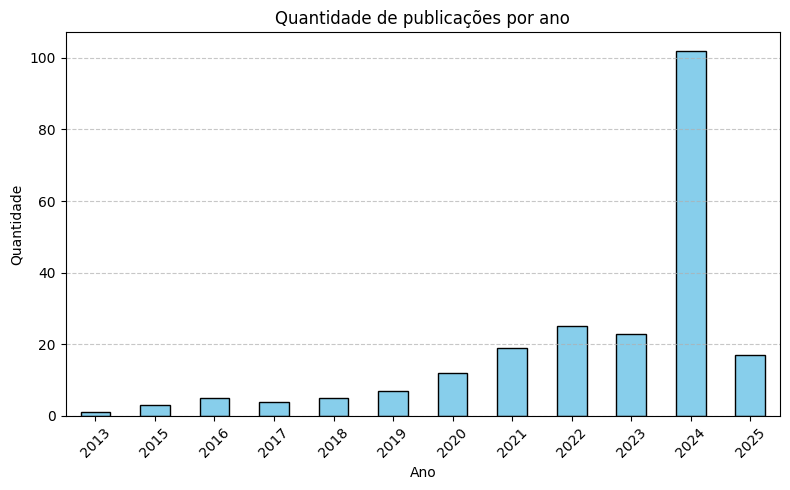

In [12]:
sentencas_final['Publicado em'] = pd.to_datetime(sentencas_final['Publicado em'], errors='coerce')
sentencas_final['Ano'] = sentencas_final['Publicado em'].dt.year
contagem_anos = sentencas_final['Ano'].value_counts().sort_index()

# 5. Plotar histograma
plt.figure(figsize=(8, 5))
contagem_anos.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Quantidade de publicações por ano')
plt.xlabel('Ano')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [18]:
ptc = contagem_anos / contagem_anos.sum() * 100
display(ptc)
display(ptc[2022]+ptc[2023]+ptc[2024])


Ano
2013     0.448430
2015     1.345291
2016     2.242152
2017     1.793722
2018     2.242152
2019     3.139013
2020     5.381166
2021     8.520179
2022    11.210762
2023    10.313901
2024    45.739910
2025     7.623318
Name: count, dtype: float64

np.float64(67.2645739910314)

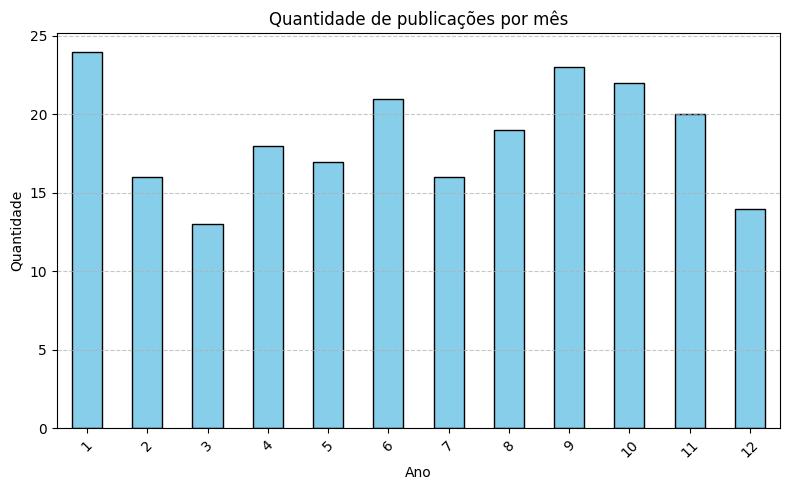

In [239]:
sentencas_final['Publicado em'] = pd.to_datetime(sentencas_final['Publicado em'], errors='coerce')
sentencas_final['mes'] = sentencas_final['Publicado em'].dt.month
contagem_mes = sentencas_final['mes'].value_counts().sort_index()

# 5. Plotar histograma
plt.figure(figsize=(8, 5))
contagem_mes.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Quantidade de publicações por mês')
plt.xlabel('Ano')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


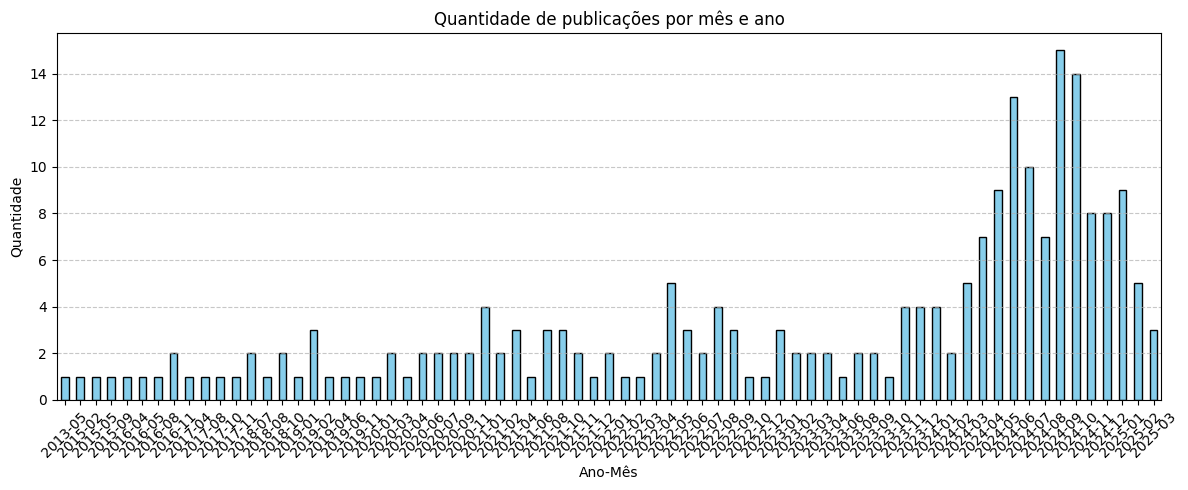

In [21]:
sentencas_final['AnoMes'] = sentencas_final['Publicado em'].dt.to_period('M').astype(str)
contagem_mensal = sentencas_final['AnoMes'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
contagem_mensal.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Quantidade de publicações por mês e ano')
plt.xlabel('Ano-Mês')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
contagem = respostas_danos_ambientais_df_completo['categoria_responsavel'].value_counts()
((contagem / contagem.sum()) * 100).round(2)



categoria_responsavel
Pessoa Jurídica    60.76
Pessoa Física      39.24
Name: count, dtype: float64

In [52]:
print(df['area_afetada'].isna().sum())
print(df['area_afetada'].notna().sum())
print((df['area_afetada'].notna().sum()/79)*100)

38
41
51.89873417721519


In [74]:
df = respostas_danos_ambientais_df_completo
#print(df['unidade_area'].unique())
filtro_m2 = df['unidade_area'].str.lower().isin(['m2', 'm²', 'metro quadrado', 'metros quadrados'])
filtro_area_nao_nan = df['area_afetada'].notna()
df_filtrado = df[filtro_m2 & filtro_area_nao_nan]
#print(df_filtrado[['unidade_area', 'area_afetada']])

print(df_filtrado['area_afetada'].describe())

count    3.900000e+01
mean     4.771573e+06
std      2.412112e+07
min      3.600000e+01
25%      1.252000e+03
50%      7.000000e+04
75%      4.214750e+05
max      1.500091e+08
Name: area_afetada, dtype: float64


In [46]:
respostas_danos_ambientais_df_completo.unidade_area.value_counts()

unidade_area
m2    39
ha     2
Name: count, dtype: int64

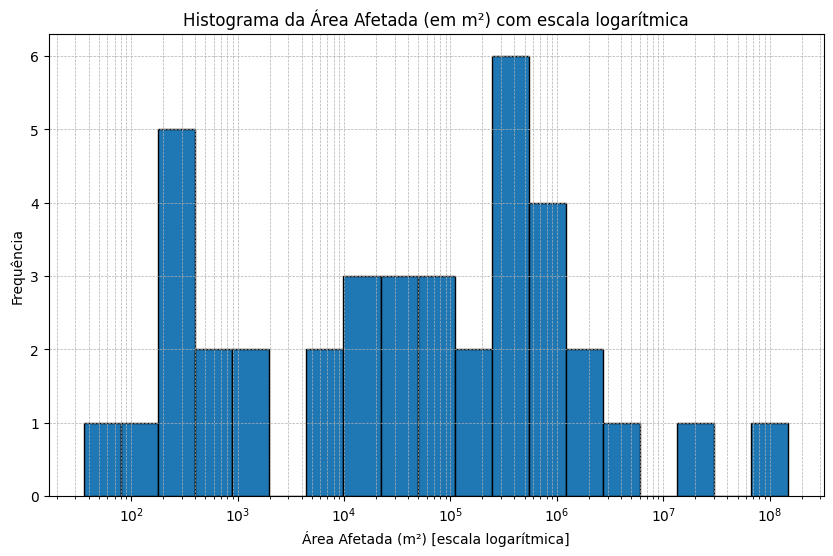

In [72]:
filtro_m2 = df['unidade_area'].str.lower().isin(['m2', 'm²', 'metro quadrado', 'metros quadrados'])
filtro_area_nao_nan = df['area_afetada'].notna()
df_filtrado = df[filtro_m2 & filtro_area_nao_nan]

valores = df_filtrado['area_afetada']
bins = np.logspace(np.log10(valores.min()), np.log10(valores.max()), 20)  # 20 bins log-spaced

plt.figure(figsize=(10,6))
plt.hist(valores, bins=bins, edgecolor='black')
plt.xscale('log')
plt.xlabel('Área Afetada (m²) [escala logarítmica]')
plt.ylabel('Frequência')
plt.title('Histograma da Área Afetada (em m²) com escala logarítmica')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()


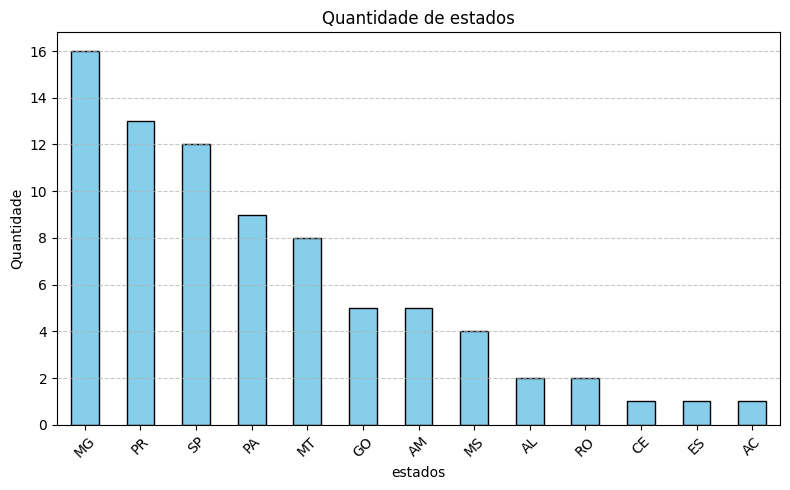

In [73]:
estados = df['uf'].value_counts()

#print(estados)
#print(((estados / estados.sum()) * 100).round(2))

plt.figure(figsize=(8, 5))
estados.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Quantidade de estados')
plt.xlabel('estados')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


C:\Users\sergi\AppData\Local\Temp\ipykernel_6800\3215474741.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['log_area'] = np.log10(df_filtrado['area_afetada'] + 1)  # +1 para evitar log(0)
C:\Users\sergi\AppData\Local\Temp\ipykernel_6800\3215474741.py:10: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df_filtrado, x='uf', y='log_area', scale='width', inner='box', cut=0)


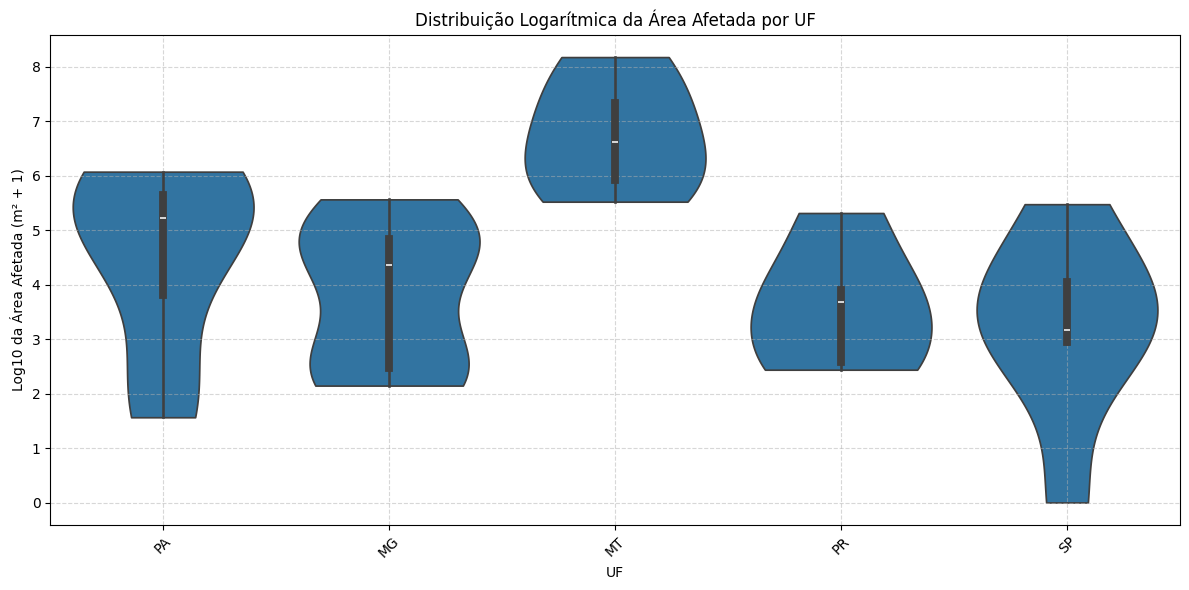

In [ ]:
estados_desejados = ['MG', 'PR', 'SP', 'PA', 'MT']
df_filtrado = df[df['uf'].isin(estados_desejados)]
df_filtrado['log_area'] = np.log10(df_filtrado['area_afetada'] + 1)  # +1 para evitar log(0)
plt.figure(figsize=(12, 6))
sns.violinplot(data=df_filtrado, x='uf', y='log_area', scale='width', inner='box', cut=0)

plt.title('Distribuição Logarítmica da Área Afetada por UF')
plt.ylabel('Log10 da Área Afetada (m² + 1)')
plt.xlabel('UF')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
print(df_filtrado['area_afetada'].describe())

In [80]:
print(df.houve_compensacao.value_counts())
df_filtrado['valor_multa'].isna().sum()

houve_compensacao
True     60
False    19
Name: count, dtype: int64


np.int64(13)

In [79]:
df_filtrado = df[df['houve_compensacao'] == True]
df_filtrado['valor_multa'].dropna().describe()

count    4.700000e+01
mean     3.542711e+05
std      7.722667e+05
min      1.537260e+03
25%      1.322978e+04
50%      5.912763e+04
75%      3.357500e+05
max      4.539354e+06
Name: valor_multa, dtype: float64

C:\Users\sergi\AppData\Local\Temp\ipykernel_6800\3279055530.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['log_area'] = np.log10(df_filtrado['valor_multa'] + 1)  # +1 para evitar log(0)
C:\Users\sergi\AppData\Local\Temp\ipykernel_6800\3279055530.py:5: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df_filtrado, x='uf', y='log_area', scale='width', inner='box', cut=0)


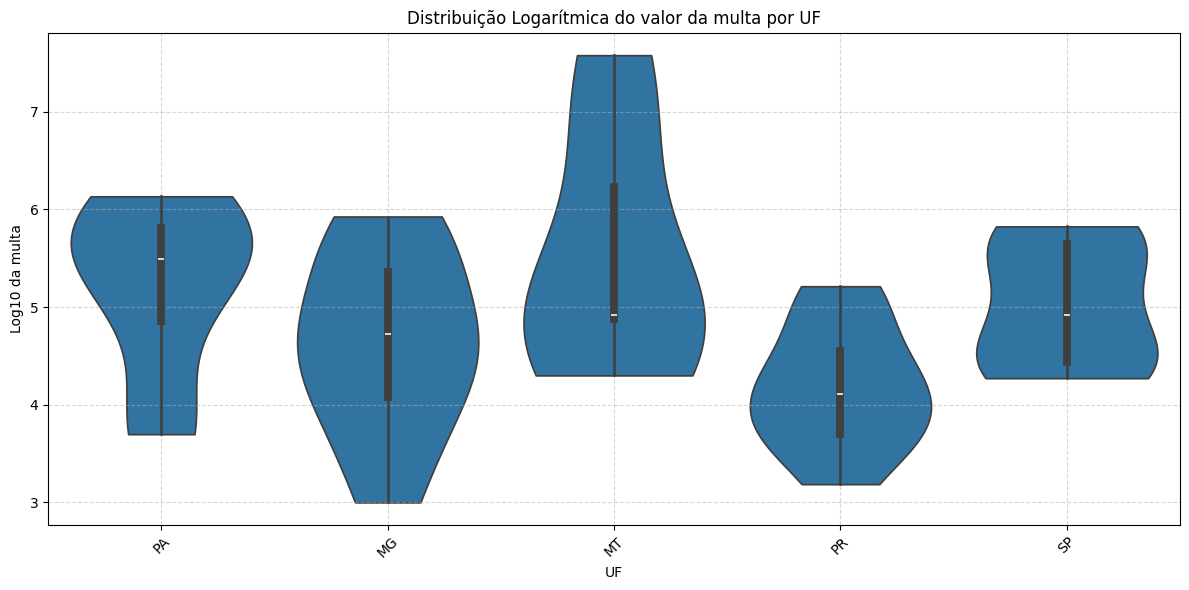

In [82]:
estados_desejados = ['MG', 'PR', 'SP', 'PA', 'MT']
df_filtrado = df[df['uf'].isin(estados_desejados)]
df_filtrado['log_area'] = np.log10(df_filtrado['valor_multa'] + 1)  # +1 para evitar log(0)
plt.figure(figsize=(12, 6))
sns.violinplot(data=df_filtrado, x='uf', y='log_area', scale='width', inner='box', cut=0)

plt.title('Distribuição Logarítmica do valor da multa por UF')
plt.ylabel('Log10 da multa')
plt.xlabel('UF')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


C:\Users\sergi\AppData\Local\Temp\ipykernel_6800\1403595694.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['log_valor_multa'] = np.log10(df_filtrado['valor_multa'] + 1)
C:\Users\sergi\AppData\Local\Temp\ipykernel_6800\1403595694.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['log_area_afetada'] = np.log10(df_filtrado['area_afetada'] + 1)


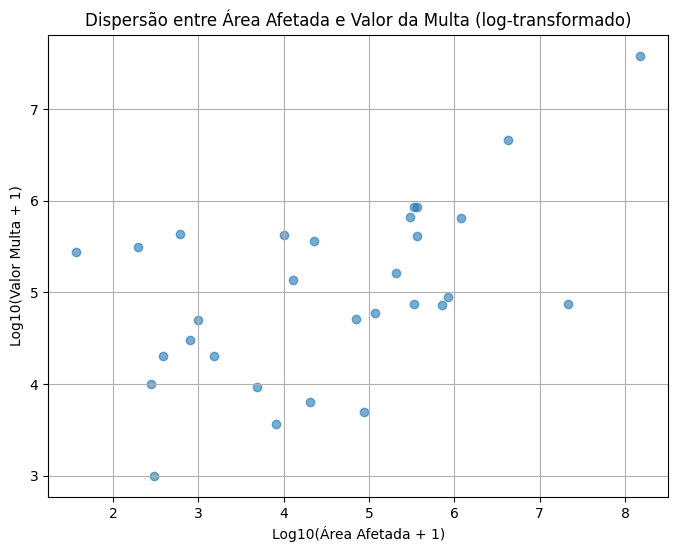

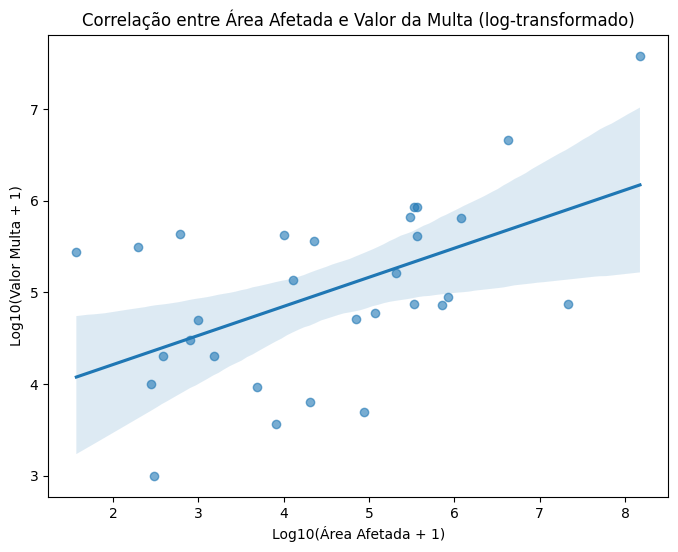

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Supondo que df_filtrado já esteja com houve_compensacao == True

# Criar colunas log-transformadas (adicionando 1 para evitar log(0))
df_filtrado['log_valor_multa'] = np.log10(df_filtrado['valor_multa'] + 1)
df_filtrado['log_area_afetada'] = np.log10(df_filtrado['area_afetada'] + 1)

# Alternativamente, usando seaborn com linha de tendência
plt.figure(figsize=(8,6))
sns.regplot(x='log_area_afetada', y='log_valor_multa', data=df_filtrado, scatter_kws={'alpha':0.6})
plt.xlabel('Log10(Área Afetada + 1)')
plt.ylabel('Log10(Valor Multa + 1)')
plt.title('Correlação entre Área Afetada e Valor da Multa (log-transformado)')
plt.show()


In [85]:
# Certifique-se que as colunas log transformadas existem
df_filtrado['log_valor_multa'] = np.log10(df_filtrado['valor_multa'] + 1)
df_filtrado['log_area_afetada'] = np.log10(df_filtrado['area_afetada'] + 1)

# Calcular a correlação de Pearson entre as duas colunas
correlacao = df_filtrado['log_valor_multa'].corr(df_filtrado['log_area_afetada'])

print(f'Coeficiente de correlação de Pearson: {correlacao:.4f}')


Coeficiente de correlação de Pearson: 0.5278


C:\Users\sergi\AppData\Local\Temp\ipykernel_6800\2484426617.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['log_valor_multa'] = np.log10(df_filtrado['valor_multa'] + 1)
C:\Users\sergi\AppData\Local\Temp\ipykernel_6800\2484426617.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['log_area_afetada'] = np.log10(df_filtrado['area_afetada'] + 1)


C:\Users\sergi\AppData\Local\Temp\ipykernel_6800\1677249499.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contagem_impactos.values, y=contagem_impactos.index, palette='viridis')


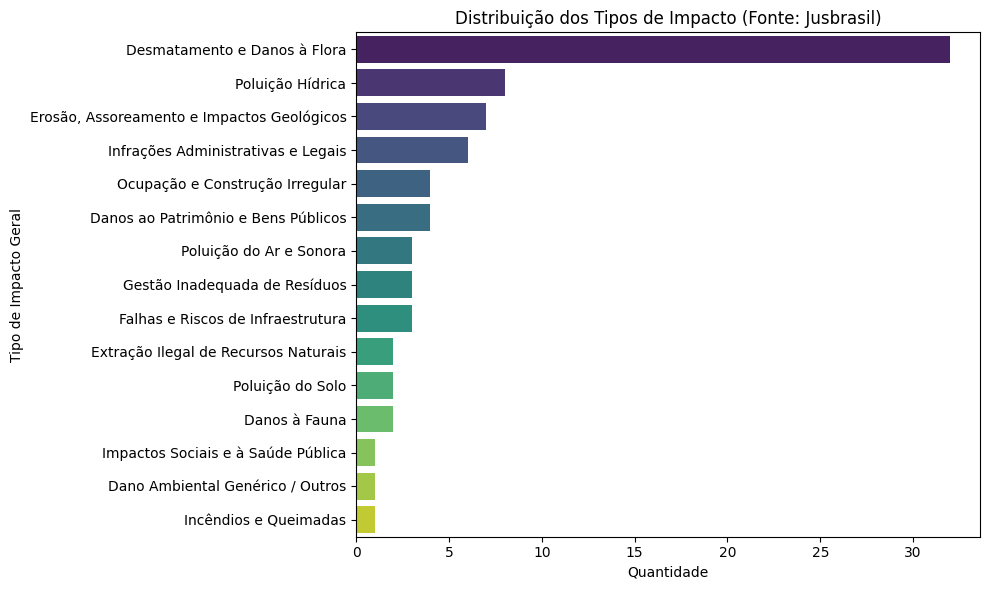

In [94]:
df_jusbrasil = df_jusbrasil_iopc_juscraper[df_jusbrasil_iopc_juscraper['fonte_dados'] == 'JusBrasil']

# Contar os tipos de impacto geral
contagem_impactos = df_jusbrasil['tipo_impacto_geral'].value_counts().sort_values(ascending=False)

# Plotar gráfico de barras
plt.figure(figsize=(10,6))
sns.barplot(x=contagem_impactos.values, y=contagem_impactos.index, palette='viridis')
plt.xlabel('Quantidade')
plt.ylabel('Tipo de Impacto Geral')
plt.title('Distribuição dos Tipos de Impacto (Fonte: Jusbrasil)')
plt.tight_layout()
plt.show()

In [95]:
contagem_impactos/contagem_impactos.sum() * 100

tipo_impacto_geral
Desmatamento e Danos à Flora                  40.506329
Poluição Hídrica                              10.126582
Erosão, Assoreamento e Impactos Geológicos     8.860759
Infrações Administrativas e Legais             7.594937
Ocupação e Construção Irregular                5.063291
Danos ao Patrimônio e Bens Públicos            5.063291
Poluição do Ar e Sonora                        3.797468
Gestão Inadequada de Resíduos                  3.797468
Falhas e Riscos de Infraestrutura              3.797468
Extração Ilegal de Recursos Naturais           2.531646
Poluição do Solo                               2.531646
Danos à Fauna                                  2.531646
Impactos Sociais e à Saúde Pública             1.265823
Dano Ambiental Genérico / Outros               1.265823
Incêndios e Queimadas                          1.265823
Name: count, dtype: float64

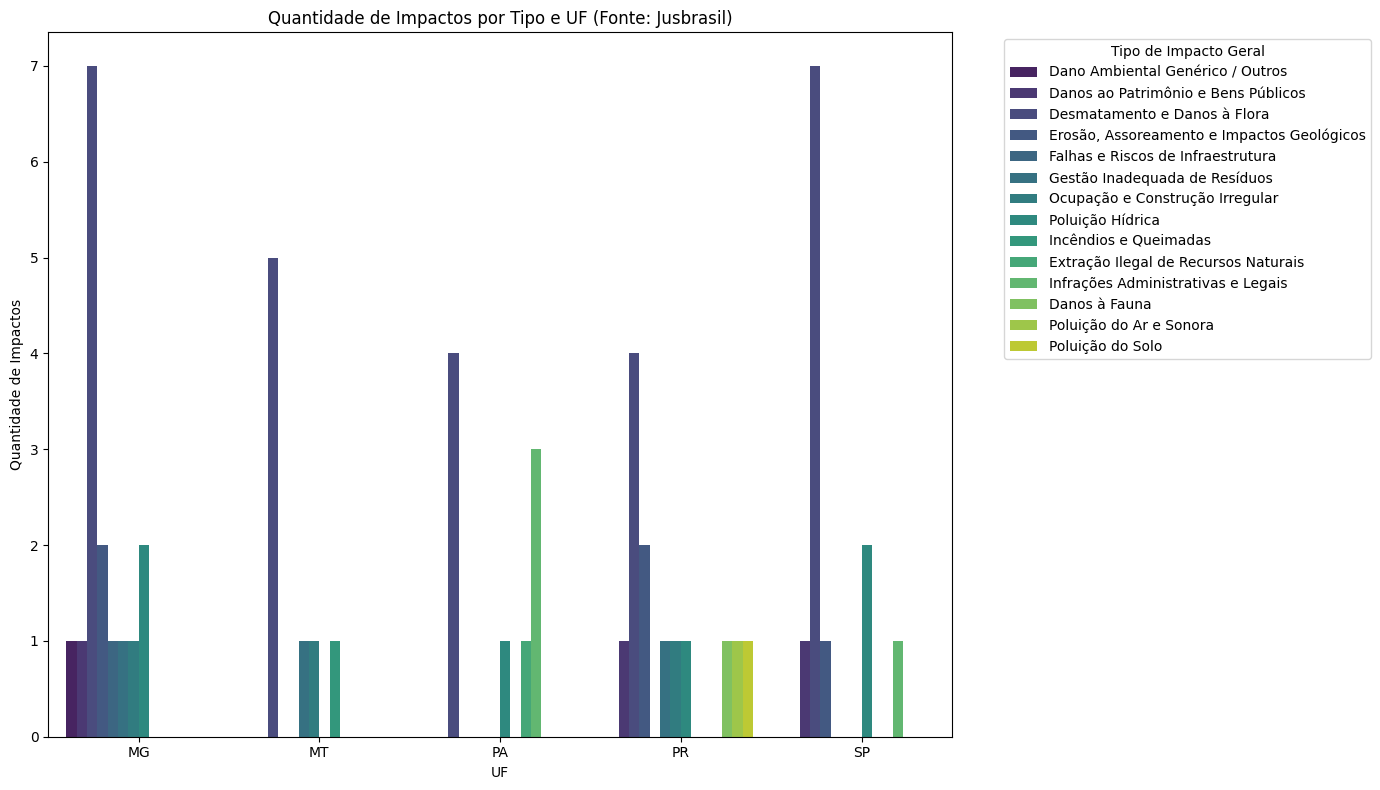

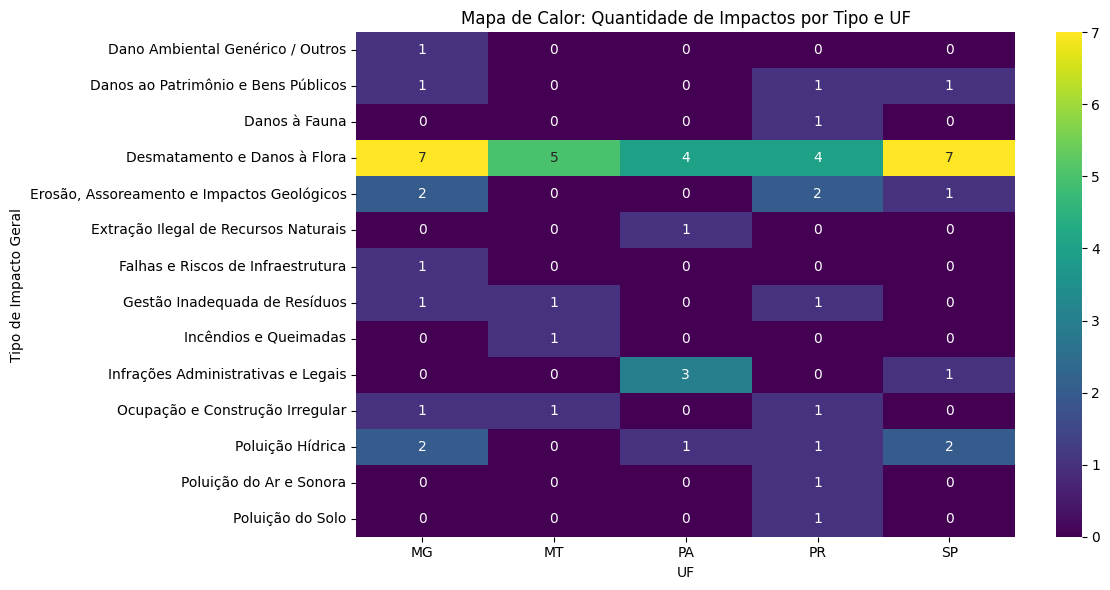

In [97]:
df_filtrado = df_jusbrasil[
    (df_jusbrasil['uf'].isin(estados_desejados))
]

contagem_uf_impacto = df_filtrado .groupby(['uf', 'tipo_impacto_geral']).size().reset_index(name='contagem')
plt.figure(figsize=(14,8))
sns.barplot(data=contagem_uf_impacto, x='uf', y='contagem', hue='tipo_impacto_geral', palette='viridis')
plt.xlabel('UF')
plt.ylabel('Quantidade de Impactos')
plt.title('Quantidade de Impactos por Tipo e UF (Fonte: Jusbrasil)')
plt.legend(title='Tipo de Impacto Geral', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
# Criar tabela pivô para heatmap
pivot_uf_impacto = contagem_uf_impacto.pivot(index='tipo_impacto_geral', columns='uf', values='contagem').fillna(0)

plt.figure(figsize=(12,6))
sns.heatmap(pivot_uf_impacto, annot=True, fmt='g', cmap='viridis')
plt.xlabel('UF')
plt.ylabel('Tipo de Impacto Geral')
plt.title('Mapa de Calor: Quantidade de Impactos por Tipo e UF')
plt.tight_layout()
plt.show()


C:\Users\sergi\AppData\Local\Temp\ipykernel_6800\1591872646.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['log_valor_multa'] = np.log10(df_filtrado['valor_multa'] + 1)
C:\Users\sergi\AppData\Local\Temp\ipykernel_6800\1591872646.py:11: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


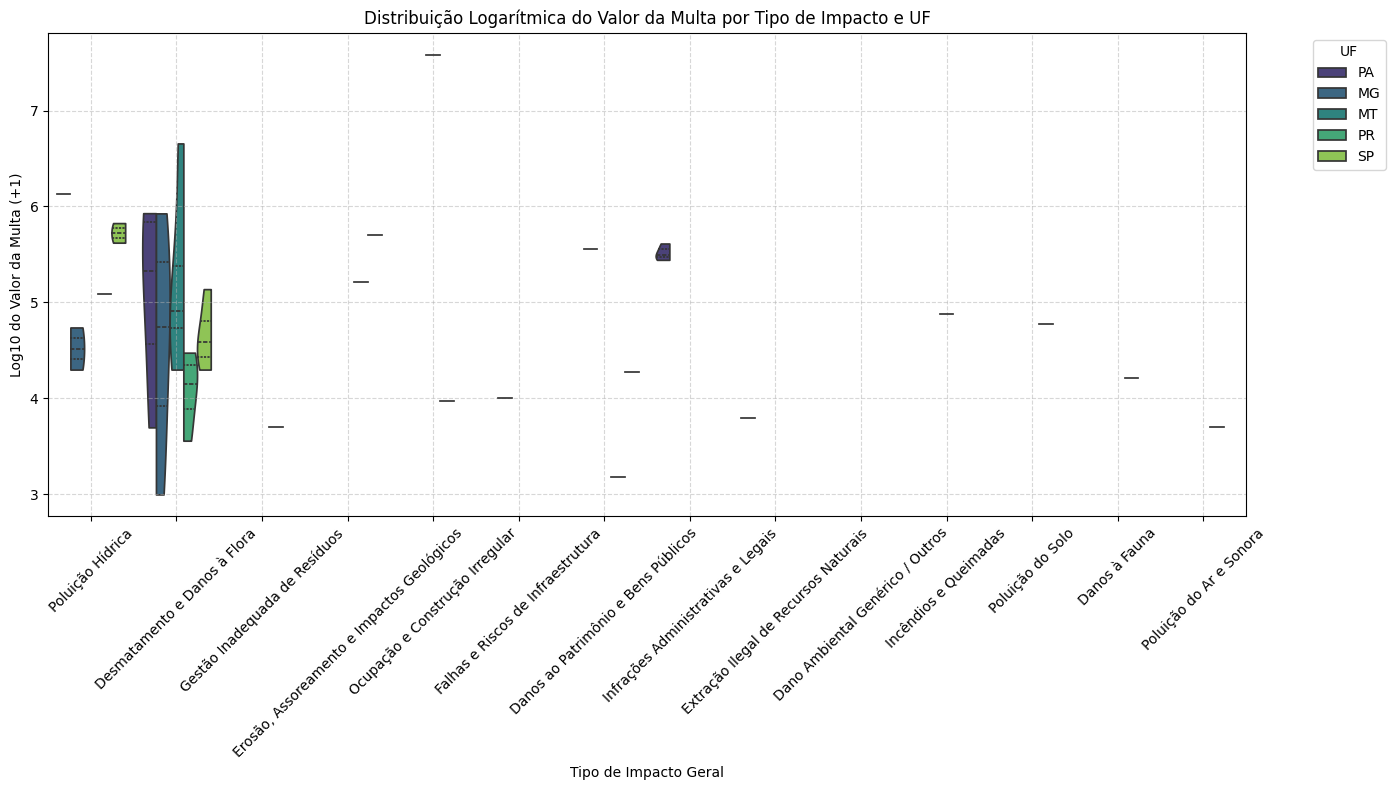

In [ ]:
df_filtrado['log_valor_multa'] = np.log10(df_filtrado['valor_multa'] + 1)
plt.figure(figsize=(14,8))
sns.violinplot(
    data=df_filtrado,
    x='tipo_impacto_geral',
    y='log_valor_multa',
    hue='uf',              
    split=True,            
    scale='width',
    inner='quartile',
    cut=0,
    palette='viridis'
)

plt.title('Distribuição Logarítmica do Valor da Multa por Tipo de Impacto e UF')
plt.ylabel('Log10 do Valor da Multa (+1)')
plt.xlabel('Tipo de Impacto Geral')
plt.xticks(rotation=45)
plt.legend(title='UF', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# Juscraper

In [113]:
juscraper = df_jusbrasil_iopc_juscraper[df_jusbrasil_iopc_juscraper['fonte_dados'] == 'Juscraper']

In [114]:
juscraper.shape

(1446, 25)

In [172]:
len(juscraper['municipio'].unique())

252

In [245]:
juscraper.columns

Index(['fonte_dados', 'numero_processo', 'processoID', 'processoAnexoID',
       'georreferencia', 'pais', 'uf', 'municipio', 'regiao', 'responsavel',
       'categoria_responsavel', 'tipo_impacto_geral', 'tipo_impacto',
       'descricao_impacto', 'data_impacto', 'area_afetada', 'unidade_area',
       'houve_compensacao', 'categoria_compensacao', 'tipo_multa',
       'valor_multa', 'valor_multa_diaria', 'moeda', 'link_referencia',
       'referencia'],
      dtype='object')

In [247]:
juscraper.categoria_responsavel.value_counts()

categoria_responsavel
Pessoa Jurídica    919
Pessoa Física      512
Name: count, dtype: int64

In [248]:
juscraper.tipo_multa.value_counts()

tipo_multa
0.0    1137
1.0     155
2.0     134
Name: count, dtype: int64

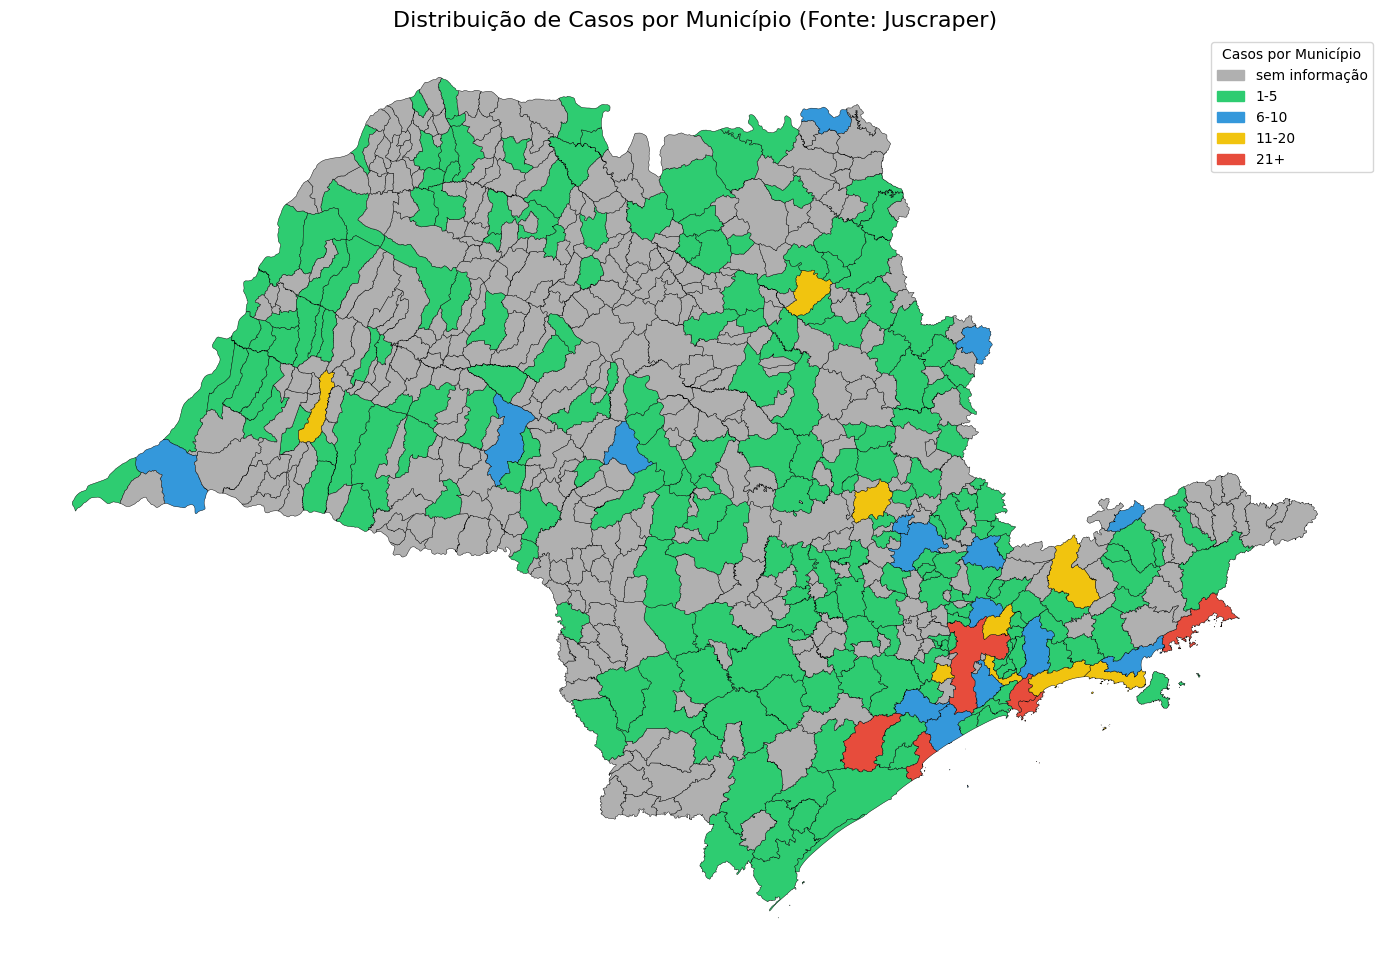

In [173]:
caminho_shapefile = r"C:\Users\sergi\OneDrive\Área de Trabalho\INSPER\entidades\insper data\2025.1\aecom\repositorio2\Projeto_InsperData_AECOM\SP_Municipios_2024\SP_Municipios_2024.shp"
gdf_sp = gpd.read_file(caminho_shapefile)

#Normalização dos nomes no shapefile
gdf_sp['municipio'] = gdf_sp['NM_MUN'].apply(lambda x: unidecode(str(x)).lower().strip())
#Filtrar apenas dados do Juscraper
juscraper = df_jusbrasil_iopc_juscraper[df_jusbrasil_iopc_juscraper['fonte_dados'] == 'Juscraper'].copy()
# Normalizar os nomes no juscraper
juscraper['municipio'] = juscraper['municipio'].apply(lambda x: unidecode(str(x)).lower().strip())
#Filtrar somente municípios que existem no shapefile (i.e., municípios de SP)
municipios_sp = set(gdf_sp['municipio'].unique())
juscraper_sp = juscraper[juscraper['municipio'].isin(municipios_sp)].copy()
# Contagem dos casos
casos_por_municipio = juscraper_sp['municipio'].value_counts().reset_index()
casos_por_municipio.columns = ['municipio', 'qtd_casos']
# Merge com o shapefile
gdf_sp_merged = gdf_sp.merge(casos_por_municipio, on='municipio', how='left')
gdf_sp_merged['qtd_casos'] = gdf_sp_merged['qtd_casos'].fillna(0)

# categórica para as faixas
def categoriza_casos(x):
    if x == 0:
        return 'sem informação'
    elif 1 <= x <= 5:
        return '1-5'
    elif 6 <= x <= 10:
        return '6-10'
    elif 11 <= x <= 20:
        return '11-20'
    else:
        return '21+'

gdf_sp_merged['categoria'] = gdf_sp_merged['qtd_casos'].apply(categoriza_casos)

# cores para cada categoria
cores = {
    'sem informação': '#B0B0B0',      
    '1-5': '#2ECC71',    
    '6-10': '#3498DB',   
    '11-20': '#F1C40F', 
    '21+': '#E74C3C'     
}
gdf_sp_merged['cor'] = gdf_sp_merged['categoria'].map(cores)
fig, ax = plt.subplots(figsize=(14, 10))
gdf_sp_merged.plot(color=gdf_sp_merged['cor'], edgecolor='black', linewidth=0.3, ax=ax)


legendas = [mpatches.Patch(color=cores[cat], label=cat) for cat in cores]
plt.legend(handles=legendas, title='Casos por Município')

plt.title('Distribuição de Casos por Município (Fonte: Juscraper)', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()


In [175]:
contagem_tipos_df = juscraper['tipo_impacto_geral'].value_counts().reset_index()
contagem_tipos_df.columns = ['tipo_impacto_geral', 'qtd_casos']
print(contagem_tipos_df)

                            tipo_impacto_geral  qtd_casos
0             Dano Ambiental Genérico / Outros        294
1                             Poluição Hídrica        294
2                 Desmatamento e Danos à Flora        293
3              Ocupação e Construção Irregular        115
4                        Incêndios e Queimadas         90
5                                Danos à Fauna         67
6                      Poluição do Ar e Sonora         66
7                             Poluição do Solo         66
8           Infrações Administrativas e Legais         64
9   Erosão, Assoreamento e Impactos Geológicos         31
10               Gestão Inadequada de Resíduos         31
11         Danos ao Patrimônio e Bens Públicos         15
12        Extração Ilegal de Recursos Naturais         10
13                    Derramamento de Petróleo          6
14          Impactos Sociais e à Saúde Pública          4


In [127]:
casos_por_municipio[casos_por_municipio["qtd_casos"] >= 21]


,municipio,qtd_casos
0,santos,498
1,miracatu,65
2,guaruja,52
3,sao paulo,37
4,peruibe,36
5,ubatuba,24


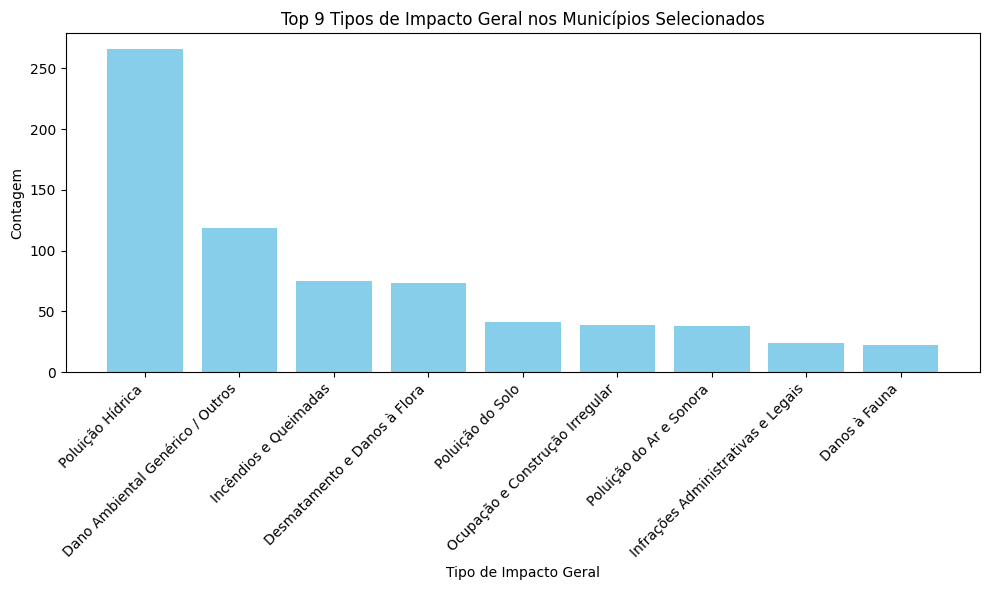

In [176]:
municipios = ['santos', 'miracatu', 'guaruja', 'sao paulo', 'peruibe', 'ubatuba']
filtro_municipios = juscraper['municipio'].str.lower().isin(municipios)
contagem_tipos = juscraper.loc[filtro_municipios, 'tipo_impacto_geral'].value_counts().reset_index()
contagem_tipos.columns = ['tipo_impacto_geral', 'contagem']

head9 = (contagem_tipos.head(9))
plt.figure(figsize=(10,6))
plt.bar(head9['tipo_impacto_geral'], head9['contagem'], color='skyblue')  # eixo x: tipos, eixo y: contagem
plt.xticks(rotation=45, ha='right')
plt.xlabel('Tipo de Impacto Geral')
plt.ylabel('Contagem')
plt.title('Top 9 Tipos de Impacto Geral nos Municípios Selecionados')
plt.tight_layout()
plt.show()


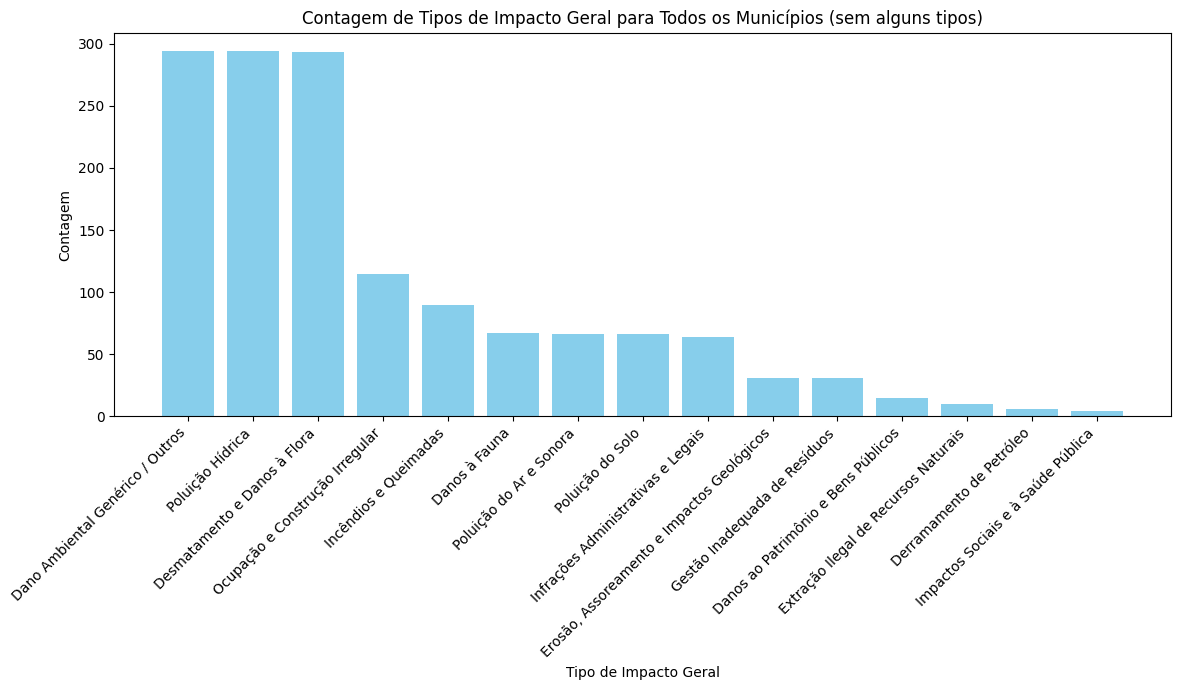

In [180]:
# Contagem geral para todos os municípios
contagem_tipos_todos = juscraper['tipo_impacto_geral'].value_counts().reset_index()
contagem_tipos_todos.columns = ['tipo_impacto', 'contagem']

# Filtrar para remover os tipos indesejados (ajuste os nomes conforme estão no seu dado)

# contagem_filtrada = contagem_tipos_todos[~contagem_tipos_todos['tipo_impacto'].str.lower().isin(tipos_para_excluir)]
# contagem_filtrada = contagem_tipos_todos.iloc[1:]  # remove a primeira linha do DataFrame
# contagem_filtrada = contagem_tipos_todos.iloc[2:]  # remove a primeira linha do DataFrame
contagem_filtrada = contagem_tipos_todos

# Plotando o gráfico com os tipos filtrados
plt.figure(figsize=(12,7))
plt.bar(contagem_filtrada['tipo_impacto'], contagem_filtrada['contagem'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Tipo de Impacto Geral')
plt.ylabel('Contagem')
plt.title('Contagem de Tipos de Impacto Geral para Todos os Municípios (sem alguns tipos)')
plt.tight_layout()
plt.show()


In [157]:
display(contagem_filtrada, head9)

,tipo_impacto,contagem
2,Desmatamento e Danos à Flora,293
3,Ocupação e Construção Irregular,115
4,Incêndios e Queimadas,90
5,Danos à Fauna,67
6,Poluição do Ar e Sonora,66
7,Poluição do Solo,66
8,Infrações Administrativas e Legais,64
9,"Erosão, Assoreamento e Impactos Geológicos",31
10,Gestão Inadequada de Resíduos,31
11,Danos ao Patrimônio e Bens Públicos,15


,tipo_impacto,contagem
0,Poluição Hídrica,266
1,Dano Ambiental Genérico / Outros,119
2,Incêndios e Queimadas,75
3,Desmatamento e Danos à Flora,73
4,Poluição do Solo,41
5,Ocupação e Construção Irregular,39
6,Poluição do Ar e Sonora,38
7,Infrações Administrativas e Legais,24
8,Danos à Fauna,22


In [161]:
# Tipos de impacto que queremos analisar (ajuste conforme seus dados)
tipos_analise = ['Desmatamento e Danos à Flora']

# Filtrar linhas onde 'tipo_impacto_geral' está em tipos_analise (ignorando caixa)
filtro_tipos = juscraper['tipo_impacto_geral'].str.lower().isin([t.lower() for t in tipos_analise])

# Filtrar só as linhas com esses tipos
df_impactos = juscraper.loc[filtro_tipos]

# Contar quantos casos por município (normalizando nomes)
contagem_por_municipio = df_impactos['municipio'].str.lower().value_counts().reset_index()

contagem_por_municipio.columns = ['municipio', 'qtd_casos']

# Ordenar do maior para o menor
contagem_por_municipio = contagem_por_municipio.sort_values(by='qtd_casos', ascending=False)

print(contagem_por_municipio)


           municipio  qtd_casos
0           miracatu         33
1            peruibe         13
2            ubatuba         13
3          sao paulo         11
4           bertioga         10
..               ...        ...
116      sao vicente          1
117          pompeia          1
118  nazare paulista          1
119    tupi paulista          1
120     itapetininga          1

[121 rows x 2 columns]


In [153]:
municipios = ['santos', 'miracatu', 'guaruja', 'sao paulo', 'peruibe', 'ubatuba']

# Filtrar só os municípios da lista
filtro_municipios = juscraper['municipio'].str.lower().isin(municipios)

# Filtrar só os casos de poluição hídrica (ignora maiúsculas/minúsculas)
# Aplicar ambos filtros
df_filtrado = juscraper.loc[filtro_municipios]

# Contar por município
contagem_por_municipio = df_filtrado['municipio'].str.lower().value_counts()

print(contagem_por_municipio)


municipio
santos       498
miracatu      65
guaruja       52
sao paulo     37
peruibe       36
ubatuba       24
Name: count, dtype: int64


In [144]:
municipios = ['santos', 'miracatu', 'guaruja', 'sao paulo', 'peruibe', 'ubatuba']

# Filtrar só os municípios da lista
filtro_municipios = juscraper['municipio'].str.lower().isin(municipios)

# Filtrar só os casos de poluição hídrica (ignora maiúsculas/minúsculas)
filtro_pol_hidrica = juscraper['tipo_impacto_geral'].str.lower() == 'poluição hídrica'

# Aplicar ambos filtros
df_filtrado = juscraper.loc[filtro_municipios & filtro_pol_hidrica]

# Contar por município
contagem_por_municipio = df_filtrado['municipio'].str.lower().value_counts()

print(contagem_por_municipio)


municipio
santos     265
ubatuba      1
Name: count, dtype: int64


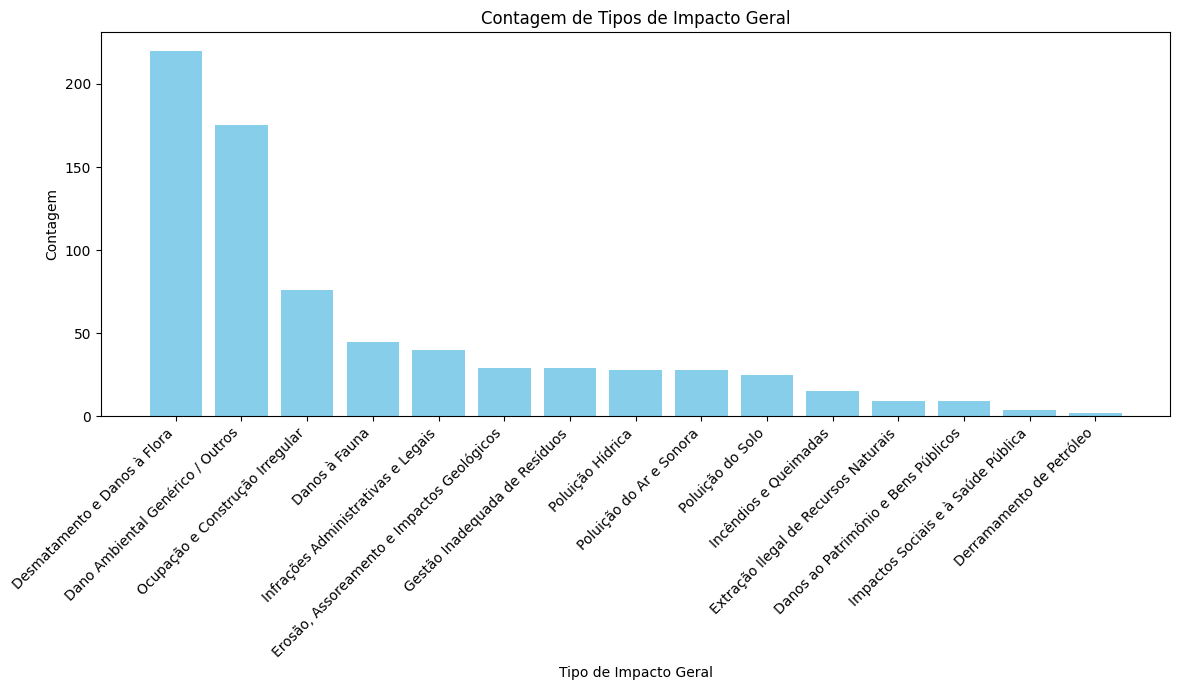

In [179]:
import matplotlib.pyplot as plt

# Criar filtro para excluir esses municípios
filtro_excluir = ~juscraper['municipio'].str.lower().isin(municipios)

# Filtrar o DataFrame para municípios não listados
df_filtrado = juscraper.loc[filtro_excluir]

# Contar os tipos de impacto geral no DataFrame filtrado
contagem_tipos_todos = df_filtrado['tipo_impacto_geral'].value_counts().reset_index()
contagem_tipos_todos.columns = ['tipo_impacto', 'contagem']


# Filtrar para remover os tipos indesejados
contagem_filtrada_restante = contagem_tipos_todos

# Plotar gráfico
plt.figure(figsize=(12,7))
plt.bar(contagem_filtrada_restante['tipo_impacto'], contagem_filtrada_restante['contagem'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Tipo de Impacto Geral')
plt.ylabel('Contagem')
plt.title('Contagem de Tipos de Impacto Geral')
plt.tight_layout()
plt.show()


In [182]:
display(contagem_filtrada,contagem_filtrada_restante)

,tipo_impacto,contagem
0,Dano Ambiental Genérico / Outros,294
1,Poluição Hídrica,294
2,Desmatamento e Danos à Flora,293
3,Ocupação e Construção Irregular,115
4,Incêndios e Queimadas,90
5,Danos à Fauna,67
6,Poluição do Ar e Sonora,66
7,Poluição do Solo,66
8,Infrações Administrativas e Legais,64
9,"Erosão, Assoreamento e Impactos Geológicos",31


,tipo_impacto,contagem
0,Desmatamento e Danos à Flora,220
1,Dano Ambiental Genérico / Outros,175
2,Ocupação e Construção Irregular,76
3,Danos à Fauna,45
4,Infrações Administrativas e Legais,40
5,"Erosão, Assoreamento e Impactos Geológicos",29
6,Gestão Inadequada de Resíduos,29
7,Poluição Hídrica,28
8,Poluição do Ar e Sonora,28
9,Poluição do Solo,25


In [192]:
tipos_desejados = [
    'Poluição Hídrica',
    'Desmatamento e Danos à Flora',
    'Ocupação e Construção Irregular',
    'Incêndios e Queimadas',
    'Danos à Fauna',
    'Poluição do Ar e Sonora',
    'Poluição do Solo',
    'Infrações Administrativas e Legais'
]
df_filtrado = juscraper[juscraper['tipo_impacto_geral'].isin(tipos_desejados)].copy()
df_filtrado['valor_multa'] = pd.to_numeric(df_filtrado['valor_multa'], errors='coerce')
df_filtrado = df_filtrado[df_filtrado['valor_multa'].notna() & (df_filtrado['valor_multa'] > 0)]

C:\Users\sergi\AppData\Local\Temp\ipykernel_6800\2583625766.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\sergi\AppData\Local\Temp\ipykernel_6800\2583625766.py:10: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


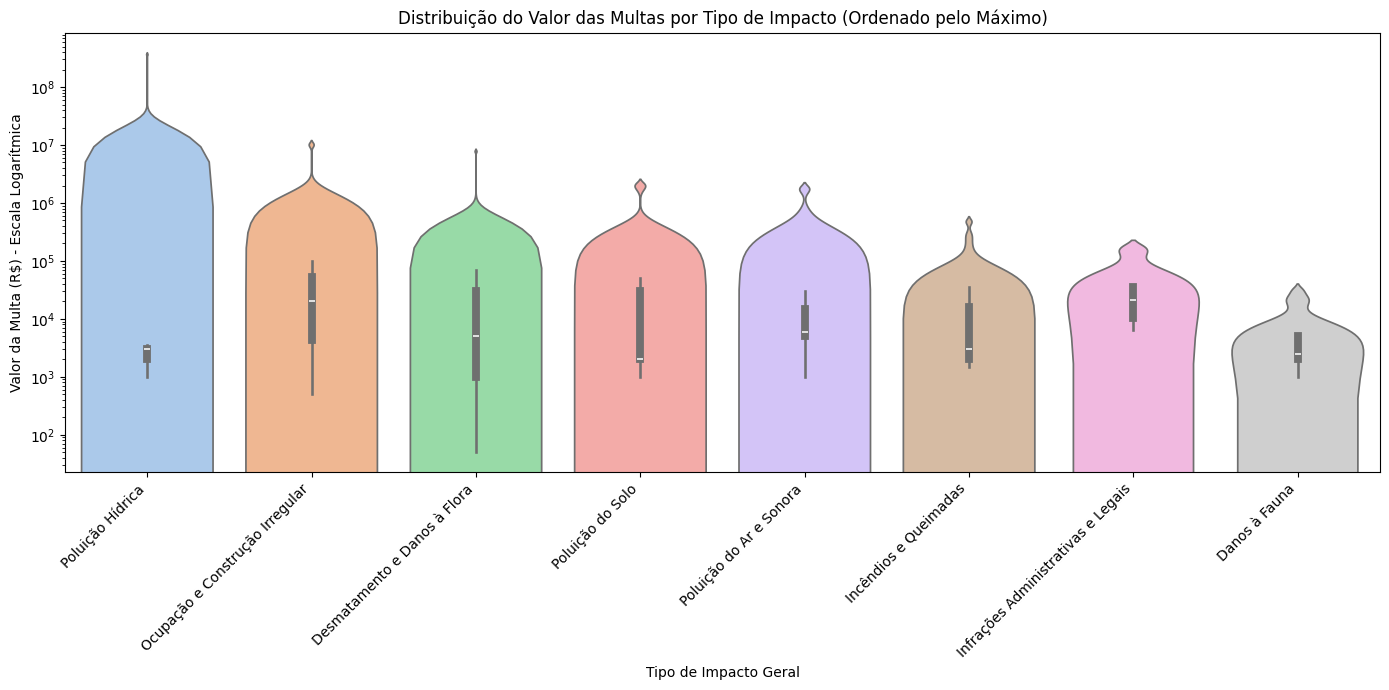

In [191]:
ordem_por_max = (
    df_filtrado.groupby('tipo_impacto_geral')['valor_multa']
    .max()
    .sort_values(ascending=False)
    .index.tolist()
)

# 2. Plotar o gráfico com a ordem desejada
plt.figure(figsize=(14,7))
sns.violinplot(
    data=df_filtrado,
    x='tipo_impacto_geral',
    y='valor_multa',
    inner='box',
    scale='width',
    palette='pastel',
    order=ordem_por_max  # Ordem com base no valor máximo
)

plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Tipo de Impacto Geral')
plt.ylabel('Valor da Multa (R$) - Escala Logarítmica')
plt.title('Distribuição do Valor das Multas por Tipo de Impacto (Ordenado pelo Máximo)')
plt.tight_layout()
plt.show()

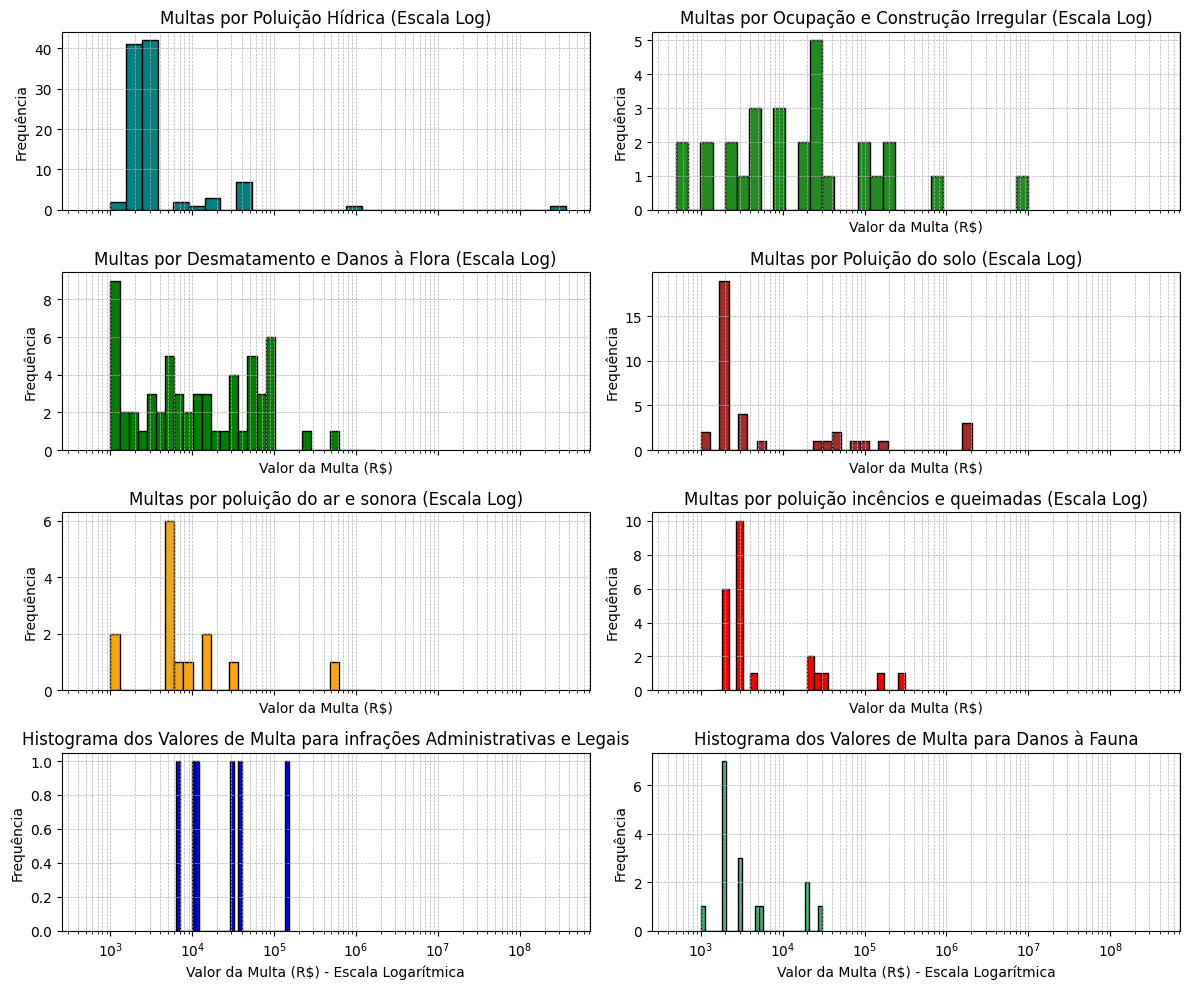

In [204]:
# Poluição Hídrica
df_Hídrica = df_filtrado[df_filtrado['tipo_impacto_geral'] == 'Poluição Hídrica']
df_Hídrica = df_Hídrica[df_Hídrica['valor_multa'] > 0]
bins_Hídrica = np.logspace(np.log10(df_Hídrica['valor_multa'].min()), 
                           np.log10(df_Hídrica['valor_multa'].max()), 30)

# Ocupação e Construção Irregular
df_irr = df_filtrado[df_filtrado['tipo_impacto_geral'] == 'Ocupação e Construção Irregular']
df_irr = df_irr[df_irr['valor_multa'] > 0]
bins_irr = np.logspace(np.log10(df_irr['valor_multa'].min()), 
                       np.log10(df_irr['valor_multa'].max()), 30)


# Desmatamento e Danos à Flora
df_desmatamento = df_filtrado[df_filtrado['tipo_impacto_geral'] == 'Desmatamento e Danos à Flora']
df_desmatamento = df_desmatamento[df_desmatamento['valor_multa'] > 0]
bins_desmatamento = np.logspace(np.log10(df_desmatamento['valor_multa'].min()), 
                                np.log10(df_desmatamento['valor_multa'].max()), 30)

#poluição do solo
df_solo= df_filtrado[df_filtrado['tipo_impacto_geral'] == 'Poluição do Solo']
df_solo = df_solo[df_solo['valor_multa'] > 0]
bins_solo = np.logspace(np.log10(df_solo['valor_multa'].min()), 
                                np.log10(df_solo['valor_multa'].max()), 30)

# Poluição do Ar e Sonora
df_ar_sonora = df_filtrado[df_filtrado['tipo_impacto_geral'] == 'Poluição do Ar e Sonora']
df_ar_sonora = df_ar_sonora[df_ar_sonora['valor_multa'] > 0]
bins_ar_sonora = np.logspace(np.log10(df_ar_sonora['valor_multa'].min()), 
                             np.log10(df_ar_sonora['valor_multa'].max()), 30)

# Incendios e Queimadas
df_incendios = df_filtrado[df_filtrado['tipo_impacto_geral'] == 'Incêndios e Queimadas']
df_incendios = df_incendios[df_incendios['valor_multa'] > 0]
bins_incendios = np.logspace(np.log10(df_incendios['valor_multa'].min()), 
                             np.log10(df_incendios['valor_multa'].max()), 30)


#Infrações Administrativas e Legais
df_Infrações = df_filtrado[df_filtrado['tipo_impacto_geral'] == 'Infrações Administrativas e Legais']
df_Infrações = df_Infrações[df_Infrações['valor_multa'] > 0]
bins_Infrações = np.logspace(np.log10(df_Infrações['valor_multa'].min()), 
                             np.log10(df_Infrações['valor_multa'].max()), 30)

# Danos à Fauna
df_fauna = df_filtrado[df_filtrado['tipo_impacto_geral'] == 'Danos à Fauna']
df_fauna = df_fauna[df_fauna['valor_multa'] > 0]
bins_log = np.logspace(np.log10(df_fauna['valor_multa'].min()), 
                       np.log10(df_fauna['valor_multa'].max()), 30)




fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 10), sharex=True)

# Poluição Hídrica
axes[0,0].hist(df_Hídrica['valor_multa'], bins=bins_Hídrica, color='teal', edgecolor='black')
axes[0,0].set_xscale('log')
axes[0,0].set_title('Multas por Poluição Hídrica (Escala Log)')
axes[0,0].set_ylabel('Frequência')
axes[0,0].grid(True, which="both", ls="--", linewidth=0.5)

# Ocupação e Construção Irregular
axes[0,1].hist(df_irr['valor_multa'], bins=bins_irr, color='forestgreen', edgecolor='black')
axes[0,1].set_xscale('log')
axes[0,1].set_title('Multas por Ocupação e Construção Irregular (Escala Log)')
axes[0,1].set_xlabel('Valor da Multa (R$)')
axes[0,1].set_ylabel('Frequência')
axes[0,1].grid(True, which="both", ls="--", linewidth=0.5)

# Desmatamento e Danos à Flora
axes[1,0].hist(df_desmatamento['valor_multa'], bins=bins_ar_sonora, color='green', edgecolor='black')
axes[1,0].set_xscale('log')
axes[1,0].set_title('Multas por Desmatamento e Danos à Flora (Escala Log)')
axes[1,0].set_xlabel('Valor da Multa (R$)')
axes[1,0].set_ylabel('Frequência')
axes[1,0].grid(True, which="both", ls="--", linewidth=0.5)

# Poluição do Solo
axes[1,1].hist(df_solo['valor_multa'], bins=bins_solo, color='brown', edgecolor='black')
axes[1,1].set_xscale('log')
axes[1,1].set_title('Multas por Poluição do solo (Escala Log)')
axes[1,1].set_xlabel('Valor da Multa (R$)')
axes[1,1].set_ylabel('Frequência')
axes[1,1].grid(True, which="both", ls="--", linewidth=0.5)

# Poluição do Ar e Sonora
axes[2,0].hist(df_ar_sonora['valor_multa'], bins=bins_ar_sonora, color='orange', edgecolor='black')
axes[2,0].set_xscale('log')
axes[2,0].set_title('Multas por poluição do ar e sonora (Escala Log)')
axes[2,0].set_xlabel('Valor da Multa (R$)')
axes[2,0].set_ylabel('Frequência')
axes[2,0].grid(True, which="both", ls="--", linewidth=0.5)

# Poluição dos Incêndios e Queimadas
axes[2,1].hist(df_incendios['valor_multa'], bins=bins_incendios, color='red', edgecolor='black')
axes[2,1].set_xscale('log')
axes[2,1].set_title('Multas por poluição incêncios e queimadas (Escala Log)')
axes[2,1].set_xlabel('Valor da Multa (R$)')
axes[2,1].set_ylabel('Frequência')
axes[2,1].grid(True, which="both", ls="--", linewidth=0.5)


# Infrações Administrativas e Legais
axes[3,0].hist(df_Infrações['valor_multa'], bins=bins_Infrações, color='blue', edgecolor='black')
axes[3,0].set_xscale('log')
axes[3,0].set_xlabel('Valor da Multa (R$) - Escala Logarítmica')
axes[3,0].set_ylabel('Frequência')
axes[3,0].set_title('Histograma dos Valores de Multa para infrações Administrativas e Legais')
axes[3,0].grid(True, which="both", ls="--", linewidth=0.5)


# Danos à Fauna
axes[3,1].hist(df_fauna['valor_multa'], bins=bins_log, color='mediumseagreen', edgecolor='black')
axes[3,1].set_xscale('log')
axes[3,1].set_xlabel('Valor da Multa (R$) - Escala Logarítmica')
axes[3,1].set_ylabel('Frequência')
axes[3,1].set_title('Histograma dos Valores de Multa para Danos à Fauna')
axes[3,1].grid(True, which="both", ls="--", linewidth=0.5)


# Ajustar layout
plt.tight_layout()
plt.show()


In [ ]:
df_irr['valor_multa'].describe()

count    2.800000e+01
mean     4.227790e+05
std      1.883268e+06
min      5.000000e+02
25%      4.354087e+03
50%      2.000000e+04
75%      5.308750e+04
max      1.000000e+07
Name: valor_multa, dtype: float64

In [206]:
df_desmatamento['valor_multa'].describe()

count    7.300000e+01
mean     1.366910e+05
std      9.008146e+05
min      5.000000e+01
25%      1.000000e+03
50%      5.000000e+03
75%      3.000000e+04
max      7.700000e+06
Name: valor_multa, dtype: float64

In [207]:
df_solo['valor_multa'].describe()

count    3.600000e+01
mean     1.767481e+05
std      5.368200e+05
min      1.000000e+03
25%      2.000000e+03
50%      2.000000e+03
75%      3.015800e+04
max      2.034766e+06
Name: valor_multa, dtype: float64

In [208]:
df_ar_sonora['valor_multa'].describe()

count    1.500000e+01
mean     1.593379e+05
std      4.529881e+05
min      1.000000e+03
25%      5.000000e+03
50%      6.000000e+03
75%      1.500000e+04
max      1.711500e+06
Name: valor_multa, dtype: float64

In [209]:
df_incendios['valor_multa'].describe()

count        26.000000
mean      40022.848846
std      104952.583031
min        1500.000000
25%        2000.000000
50%        3000.000000
75%       16104.400000
max      469783.230000
Name: valor_multa, dtype: float64

In [210]:
df_Infrações['valor_multa'].describe()

count         6.000000
mean      40886.265000
std       54815.909611
min        6310.630000
25%       10496.500000
50%       20993.000000
75%       35265.720000
max      150000.000000
Name: valor_multa, dtype: float64

In [211]:
df_fauna['valor_multa'].describe()

count       16.000000
mean      6531.250000
std       8674.615746
min       1000.000000
25%       2000.000000
50%       2500.000000
75%       5125.000000
max      30000.000000
Name: valor_multa, dtype: float64

# IOPC

In [212]:
iopc = df_jusbrasil_iopc_juscraper[df_jusbrasil_iopc_juscraper['fonte_dados'] == 'IOPC']

In [214]:
len(iopc.pais.unique())

17

In [215]:
iopc.shape

(70, 25)

In [216]:
iopc.columns

Index(['fonte_dados', 'numero_processo', 'processoID', 'processoAnexoID',
       'georreferencia', 'pais', 'uf', 'municipio', 'regiao', 'responsavel',
       'categoria_responsavel', 'tipo_impacto_geral', 'tipo_impacto',
       'descricao_impacto', 'data_impacto', 'area_afetada', 'unidade_area',
       'houve_compensacao', 'categoria_compensacao', 'tipo_multa',
       'valor_multa', 'valor_multa_diaria', 'moeda', 'link_referencia',
       'referencia'],
      dtype='object')

C:\Users\sergi\AppData\Local\Temp\ipykernel_6800\778297779.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iopc['data_impacto'] = pd.to_datetime(iopc['data_impacto'], errors='coerce')
C:\Users\sergi\AppData\Local\Temp\ipykernel_6800\778297779.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iopc['Ano'] = iopc['data_impacto'].dt.year


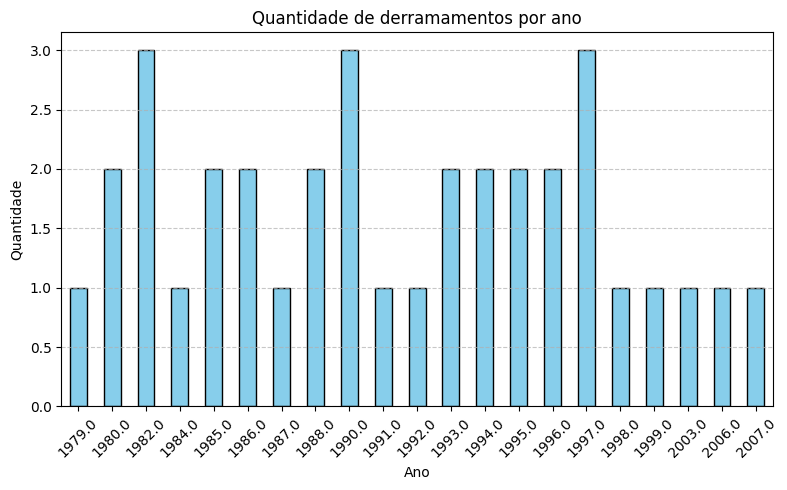

In [229]:
iopc['data_impacto'] = pd.to_datetime(iopc['data_impacto'], errors='coerce')
iopc['Ano'] = iopc['data_impacto'].dt.year
contagem_anos = iopc['Ano'].value_counts().sort_index()

# 5. Plotar histograma
plt.figure(figsize=(8, 5))
contagem_anos.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Quantidade de derramamentos por ano')
plt.xlabel('Ano')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [223]:
cc = coco.CountryConverter()

# Cria a nova coluna com o continente correspondente
iopc['continente'] = iopc['pais'].apply(
    lambda x: cc.convert(names=x, to='continent') if pd.notnull(x) else None
)

 USSR not found in regex
 USSR not found in regex
C:\Users\sergi\AppData\Local\Temp\ipykernel_6800\1524809801.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iopc['continente'] = iopc['pais'].apply(


In [228]:
iopc['continente'].value_counts()

continente
Asia         49
Europe       17
not found     2
America       1
Name: count, dtype: int64

In [230]:
iopc['pais'].value_counts()

pais
Japan                          34
Republic of Korea              13
France                          3
United Kingdom                  3
USSR                            2
Germany                         2
Sweden                          2
Greece                          2
United Arab Emirates            1
Finland                         1
Russia                          1
Republic of the Philippines     1
Estonia                         1
Spain                           1
Canada                          1
Denmark                         1
Name: count, dtype: int64

In [235]:
iopc.loc[iopc['continente'] == 'Europe', 'pais']


79              France
80              Greece
86              Russia
88             Finland
97      United Kingdom
99              Greece
107     United Kingdom
109              Spain
110            Estonia
119             Sweden
121     United Kingdom
127            Denmark
128            Germany
130             Sweden
132             France
138             France
142            Germany
Name: pais, dtype: object

In [236]:
iopc.loc[iopc['continente'] == 'not found', 'pais']


123     USSR
141     USSR
Name: pais, dtype: object

C:\Users\sergi\AppData\Local\Temp\ipykernel_6800\143750151.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iopc['mes'] = iopc['data_impacto'].dt.month


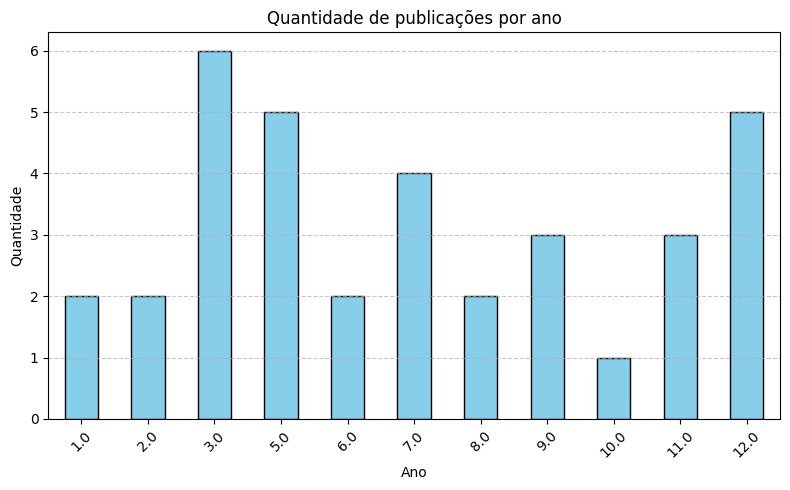

In [ ]:
iopc['mes'] = iopc['data_impacto'].dt.month
contagem_mes = iopc['mes'].value_counts().sort_index()

# 5. Plotar histograma
plt.figure(figsize=(8, 5))
contagem_mes.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Quantidade de derramamentos por mês')
plt.xlabel('Ano')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [242]:
iopc.area_afetada.value_counts()

Series([], Name: count, dtype: int64)

# Junção de bases

In [249]:
juncao = df_jusbrasil_iopc_juscraper

In [250]:
juncao.shape

(1595, 25)

In [257]:
x = juncao.fonte_dados.value_counts()
display(x,x/x.sum() * 100)

fonte_dados
Juscraper    1446
JusBrasil      79
IOPC           70
Name: count, dtype: int64

fonte_dados
Juscraper    90.658307
JusBrasil     4.952978
IOPC          4.388715
Name: count, dtype: float64

In [262]:
juncao.georreferencia.notna().sum()


np.int64(46)

In [266]:
juncao.categoria_compensacao.value_counts()

categoria_compensacao
Custas Judiciais e Acordos         561
Obrigações de Fazer (com custo)    534
Multas Administrativas              66
Compensações Financeiras            25
Valoração Econômica                  2
Name: count, dtype: int64

In [269]:
juncao.tipo_multa.value_counts()

tipo_multa
0.0    1187
1.0     161
2.0     156
Name: count, dtype: int64

In [270]:
1187/(1187+161+156)

0.7892287234042553